In [4]:
# CELL 1 - Khai báo thư viện và thiết lập tái lập kết quả
# Mục tiêu: import thư viện cần dùng, cố định seed và chọn thiết bị chạy.
# Giữ một SEED chung giúp các mô hình được so sánh trong cùng điều kiện ngẫu nhiên.

import warnings
warnings.filterwarnings("ignore")

import copy
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf


SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("SEED:", SEED)


DEVICE: cpu
SEED: 42


In [5]:
# CELL 2 - Cấu hình dữ liệu và tham số mô hình
# Mục tiêu: khai báo danh sách mã cổ phiếu, khoảng thời gian, feature đầu vào và kích thước mô hình.
# Các tham số ở đây là điểm điều chỉnh chính khi muốn thử nghiệm lại.

TICKERS = [
    "AAPL", "ADBE", "AMD", "CMCSA", "COST",
    "INTC", "INTU", "MSFT", "QCOM", "SBUX"
]

START_DATE = "2005-01-01"
END_DATE   = "2024-01-01"

FEATURE_COLS = [
    "Close",
    "Volume",
    "Return",
    "MA5",
    "MA20",
    "Volatility5",
    "Volatility20"
]

TARGET_COL = "Close"
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

LOOKBACK = 20
DIRECTION_EPS = 0.0

LSTM_HIDDEN = 64
GNN_HIDDEN = 32
MLP_HIDDEN = 64
DROPOUT = 0.2

print("TICKERS:", TICKERS)
print("FEATURE_COLS:", FEATURE_COLS)
print("LOOKBACK:", LOOKBACK)


TICKERS: ['AAPL', 'ADBE', 'AMD', 'CMCSA', 'COST', 'INTC', 'INTU', 'MSFT', 'QCOM', 'SBUX']
FEATURE_COLS: ['Close', 'Volume', 'Return', 'MA5', 'MA20', 'Volatility5', 'Volatility20']
LOOKBACK: 20


In [6]:
# CELL 3 - Tải dữ liệu và tạo feature kỹ thuật
# Mục tiêu: tải dữ liệu từng mã, làm sạch dữ liệu và tạo MA/volatility/return.
# Feature được tạo theo từng ticker trước khi ghép thành bộ dữ liệu chung.

def download_one_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False
    )

    if df.empty:
        raise ValueError(f"Không tải được dữ liệu cho {ticker}")

    # Nếu yfinance trả về multi-index columns thì đưa về tên cột đơn.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    keep_cols = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    df = df[keep_cols].copy()

    df["Close"] = df["Close"].ffill()
    df["Volume"] = df["Volume"].fillna(0.0)

    df["Return"] = df["Close"].pct_change().fillna(0.0)
    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["Volatility5"] = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()

    df = df.dropna().copy()
    df.index = pd.to_datetime(df.index)
    return df


data_dict = {}
for ticker in TICKERS:
    data_dict[ticker] = download_one_ticker(ticker, START_DATE, END_DATE)

# Giao ngày giữa tất cả mã để mỗi timestep có đủ dữ liệu cho mỗi ticker.
common_index = None
for ticker in TICKERS:
    idx = data_dict[ticker].index
    common_index = idx if common_index is None else common_index.intersection(idx)

common_index = common_index.sort_values()

for ticker in TICKERS:
    data_dict[ticker] = data_dict[ticker].loc[common_index].copy()

print("Số ngày chung:", len(common_index))
print("Ngày đầu:", common_index.min())
print("Ngày cuối:", common_index.max())

for ticker in TICKERS[:3]:
    print(ticker, data_dict[ticker].shape)
    print(data_dict[ticker].head(2))
    print()


Số ngày chung: 4762
Ngày đầu: 2005-01-31 00:00:00
Ngày cuối: 2023-12-29 00:00:00
AAPL (4762, 10)
                Open      High       Low     Close      Volume    Return  \
Date                                                                       
2005-01-31  1.331786  1.390893  1.330536  1.373214  1681097600  0.039470   
2005-02-01  1.375893  1.388750  1.367500  1.384464   678395200  0.008192   

                 MA5      MA20  Volatility5  Volatility20  
Date                                                       
2005-01-31  1.313643  1.236223     0.014537      0.027765  
2005-02-01  1.333214  1.248937     0.014988      0.027667  

ADBE (4762, 10)
                 Open       High        Low      Close   Volume    Return  \
Date                                                                        
2005-01-31  28.100000  28.665001  27.930000  28.450001  6100600  0.025595   
2005-02-01  28.450001  29.184999  28.450001  28.950001  4639600  0.017575   

               MA5      MA20  Vo

In [7]:
# CELL 4 - Chuyển dữ liệu thành tensor 3 chiều
# Mục tiêu: gom dữ liệu thành dạng [thời gian, số mã, số feature] để dùng chung cho các mô hình.
# Chỉ giữ những ngày xuất hiện đầy đủ ở tất cả ticker để tránh lệch index.

def build_feature_tensor(data_dict: Dict[str, pd.DataFrame],
                         tickers: List[str],
                         feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    dates = data_dict[tickers[0]].index

    T = len(dates)
    N = len(tickers)
    F = len(feature_cols)

    features_3d = np.zeros((T, N, F), dtype=np.float32)
    close_2d = np.zeros((T, N), dtype=np.float32)
    return_2d = np.zeros((T, N), dtype=np.float32)

    for j, ticker in enumerate(tickers):
        df = data_dict[ticker]

        features_3d[:, j, :] = df[feature_cols].values.astype(np.float32)
        close_2d[:, j] = df["Close"].values.astype(np.float32)
        return_2d[:, j] = df["Return"].values.astype(np.float32)

    return features_3d, close_2d, return_2d, dates


features_3d, close_2d, return_2d, dates = build_feature_tensor(
    data_dict=data_dict,
    tickers=TICKERS,
    feature_cols=FEATURE_COLS
)

print("features_3d:", features_3d.shape)
print("close_2d:", close_2d.shape)
print("return_2d:", return_2d.shape)
print("dates:", len(dates))


features_3d: (4762, 10, 7)
close_2d: (4762, 10)
return_2d: (4762, 10)
dates: 4762


In [8]:
# CELL 5 - Hàm tiện ích đánh giá và chuẩn hóa graph
# Mục tiêu: chuẩn hóa ma trận kề và tính MSE, MAE, RMSE, Directional Accuracy.
# Các hàm này được dùng lại cho Linear, LSTM và hai biến thể Hybrid.

def normalize_adjacency(adj: np.ndarray) -> np.ndarray:
    """
    Chuẩn hóa đối xứng ma trận kề: D^{-1/2} A D^{-1/2}.
    adj: [N, N]
    """
    adj = adj.astype(np.float32)
    deg = adj.sum(axis=1)
    deg_inv_sqrt = np.power(np.maximum(deg, 1e-8), -0.5)
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt
    return adj_norm.astype(np.float32)


def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    last_close: np.ndarray,
                    eps: float = 0.0):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    last_f = last_close.reshape(-1)

    mse = mean_squared_error(y_true_f, y_pred_f)
    mae = mean_absolute_error(y_true_f, y_pred_f)
    rmse = float(np.sqrt(mse))

    true_up = (y_true_f - last_f) > eps
    pred_up = (y_pred_f - last_f) > eps
    directional_accuracy = float((true_up == pred_up).mean())

    return {
        "MSE": float(mse),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Directional_Accuracy": directional_accuracy
    }


In [9]:
# CELL 6 - Dataset cho mô hình graph/time-series
# Mục tiêu: đóng gói sequence, node feature, adjacency, target và last close cho DataLoader.
# Dataset giữ cùng format dữ liệu để LSTM và Hybrid có thể train trong cùng pipeline.

class StockGraphDataset(Dataset):
    def __init__(self, X_seq, X_node, A, y_res, y_close, last_close):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_node = torch.tensor(X_node, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.float32)
        self.y_res = torch.tensor(y_res, dtype=torch.float32)
        self.y_close = torch.tensor(y_close, dtype=torch.float32)
        self.last_close = torch.tensor(last_close, dtype=torch.float32)

    def __len__(self):
        return len(self.y_close)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.X_node[idx],
            self.A[idx],
            self.y_res[idx],
            self.y_close[idx],
            self.last_close[idx]
        )


In [10]:
# CELL 7 - Mô hình nền: GCN layer và LSTM baseline
# Mục tiêu: định nghĩa lớp GCN đơn giản và mô hình LSTM chỉ dùng chuỗi giá đóng cửa.
# LSTM baseline là nền để so sánh mức cải thiện của phần graph.

class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        x:   [B, N, F]
        adj: [B, N, N]
        """
        h = self.linear(x)
        out = torch.bmm(adj, h)
        return out


class LSTMOnlyModel(nn.Module):
    def __init__(self, input_dim=1, lstm_hidden=64, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(
        self,
        seq: torch.Tensor,
        node_x: torch.Tensor = None,
        adj: torch.Tensor = None,
        last_close: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        seq: [batch, số mã, lookback, số feature]
        last_close: [batch, số mã]

        Pipeline train dùng chung chữ ký forward(seq, node_x, adj, last_close)
        cho cả LSTM và Hybrid. LSTM baseline bỏ qua node_x/adj và chỉ lấy
        feature close ở cột đầu tiên để giữ đúng vai trò mô hình chuỗi thuần.
        """
        if last_close is None:
            # Hỗ trợ trường hợp gọi cũ: model(seq, last_close).
            last_close = node_x

        B, N, T, F = seq.shape
        close_seq = seq[..., :1]
        seq_flat = close_seq.reshape(B * N, T, 1)

        out, _ = self.lstm(seq_flat)
        h = out[:, -1, :]
        h = self.dropout(h)

        pred_res = self.fc(h).reshape(B, N)
        pred_close = last_close + pred_res
        return pred_close


In [11]:
# CELL 8 - Hàm huấn luyện, validation và dự đoán
# Mục tiêu: dùng chung một quy trình train/evaluate/predict cho LSTM và Hybrid.
# Loss chính là MSE; Hybrid có thêm loss phụ cho chiều tăng/giảm để ổn định Directional Accuracy.

def compute_model_loss(model, pred_close, y_close, last_close):
    mse_loss = nn.functional.mse_loss(pred_close, y_close)

    direction_weight = float(getattr(model, "direction_loss_weight", 0.0))
    if direction_weight <= 0:
        return mse_loss

    logit_scale = float(getattr(model, "direction_logit_scale", 50.0))
    direction_target = (y_close - last_close > DIRECTION_EPS).float()
    direction_logits = (pred_close - last_close) * logit_scale
    direction_loss = nn.functional.binary_cross_entropy_with_logits(
        direction_logits,
        direction_target
    )

    return mse_loss + direction_weight * direction_loss


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in train_one_epoch.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        optimizer.zero_grad()
        pred_close = model(seq, node_x, adj, last_close)
        loss = compute_model_loss(model, pred_close, y_close, last_close)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in evaluate_loss.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close)
        loss = compute_model_loss(model, pred_close, y_close, last_close)
        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close_device)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)

    return preds, trues, lasts


def fit_model_silent(model, train_loader, val_loader, epochs, lr, patience, device, verbose=False):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # Include the initial state in early stopping. This is important for
    # hybrid models that start from a trained LSTM backbone.
    best_state = copy.deepcopy(model.state_dict())
    best_val = evaluate_loss(model, val_loader, criterion, device)
    wait = 0

    history = {"train_loss": [], "val_loss": [], "initial_val_loss": best_val}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [12]:
# CELL 9 - Cấu hình expanding-window và graph
# Mục tiêu: khai báo số ngày test, số epoch, learning rate, tham số graph và tham số ổn định hybrid.
# Các giá trị này quyết định protocol backtest và mức đóng góp của graph gate.

EXP_WARM_START = True
EXP_TEST_DAYS = 50
EXP_INITIAL_TRAIN_DAYS = 252 * 2
EXP_VAL_DAYS = 50

EXP_BATCH_SIZE = 11

EXP_USE_FAST_MODE = True

EXP_FAST_INIT_EPOCHS = 20
EXP_FAST_UPDATE_EPOCHS = 6
EXP_FAST_PATIENCE = 5

EXP_FINAL_INIT_EPOCHS = 40
EXP_FINAL_UPDATE_EPOCHS = 8
EXP_FINAL_PATIENCE = 5

EXP_INIT_EPOCHS = EXP_FAST_INIT_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_INIT_EPOCHS
EXP_UPDATE_EPOCHS = EXP_FAST_UPDATE_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_UPDATE_EPOCHS
EXP_PATIENCE = EXP_FAST_PATIENCE if EXP_USE_FAST_MODE else EXP_FINAL_PATIENCE

EXP_LR_LSTM = 0.005
EXP_LR_HYBRID = 0.005

EXP_LINEAR_RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

EXP_GRAPH_RESIDUAL_SCALE = 0.25
EXP_HYBRID_DIRECTION_LOSS_WEIGHT = 0.02
EXP_DIRECTION_LOGIT_SCALE = 50.0
EXP_INIT_HYBRID_FROM_LSTM = True
EXP_INIT_GRAPH_GATE_FROM_NO_GATE = True
EXP_GRAPH_GATE_DELTA_SCALE = 0.50

EXP_GRAPH_RECENT_DAYS = 252 * 2
EXP_PEARSON_THRESHOLD = 0.70
EXP_PEARSON_TOPK = 5

EXP_ASSOC_RECENT_DAYS = 252 * 2
EXP_ASSOC_MIN_SUPPORT = 0.05
EXP_ASSOC_MIN_CONFIDENCE = 0.10
EXP_ASSOC_LIFT_THRESHOLD = 1.50
EXP_ASSOC_TOPK = 3
EXP_ASSOC_EDGE_WEIGHT = 0.50

EXP_FINAL_GRAPH_TOPK = 4

print("Using one global SEED:", SEED)
print("EXP_USE_FAST_MODE:", EXP_USE_FAST_MODE)
print("EXP_INIT_EPOCHS:", EXP_INIT_EPOCHS)
print("EXP_UPDATE_EPOCHS:", EXP_UPDATE_EPOCHS)
print("EXP_BATCH_SIZE:", EXP_BATCH_SIZE)
print("EXP_LR_LSTM:", EXP_LR_LSTM)
print("EXP_LR_HYBRID:", EXP_LR_HYBRID)
print("EXP_LINEAR_RIDGE_ALPHAS:", EXP_LINEAR_RIDGE_ALPHAS)
print("EXP_GRAPH_RESIDUAL_SCALE:", EXP_GRAPH_RESIDUAL_SCALE)
print("EXP_HYBRID_DIRECTION_LOSS_WEIGHT:", EXP_HYBRID_DIRECTION_LOSS_WEIGHT)
print("EXP_INIT_HYBRID_FROM_LSTM:", EXP_INIT_HYBRID_FROM_LSTM)
print("EXP_INIT_GRAPH_GATE_FROM_NO_GATE:", EXP_INIT_GRAPH_GATE_FROM_NO_GATE)
print("EXP_GRAPH_GATE_DELTA_SCALE:", EXP_GRAPH_GATE_DELTA_SCALE)
print("EXP_PEARSON_THRESHOLD:", EXP_PEARSON_THRESHOLD)
print("EXP_ASSOC_LIFT_THRESHOLD:", EXP_ASSOC_LIFT_THRESHOLD)


Using one global SEED: 42
EXP_USE_FAST_MODE: True
EXP_INIT_EPOCHS: 20
EXP_UPDATE_EPOCHS: 6
EXP_BATCH_SIZE: 11
EXP_LR_LSTM: 0.005
EXP_LR_HYBRID: 0.005
EXP_LINEAR_RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0]
EXP_GRAPH_RESIDUAL_SCALE: 0.25
EXP_HYBRID_DIRECTION_LOSS_WEIGHT: 0.02
EXP_INIT_HYBRID_FROM_LSTM: True
EXP_INIT_GRAPH_GATE_FROM_NO_GATE: True
EXP_GRAPH_GATE_DELTA_SCALE: 0.5
EXP_PEARSON_THRESHOLD: 0.7
EXP_ASSOC_LIFT_THRESHOLD: 1.5


In [13]:
# CELL 10 - Chuẩn hóa dữ liệu tránh leakage
# Mục tiêu: fit scaler chỉ trên cửa sổ train ban đầu, sau đó transform toàn bộ chuỗi.
# Cách này giúp scaler không nhìn trước phân phối của giai đoạn test.

def fit_and_scale_for_expanding_initial_window(raw_features_3d, first_test_t, initial_train_days):
    T, N, F = raw_features_3d.shape

    train_start_t = max(0, first_test_t - initial_train_days)
    train_end_t = first_test_t - 1

    scaled = np.zeros_like(raw_features_3d, dtype=np.float32)
    scalers = []
    close_mins = []
    close_maxs = []

    for j in range(N):
        scaler = MinMaxScaler()
        scaler.fit(raw_features_3d[train_start_t:train_end_t + 1, j, :])

        scaled[:, j, :] = scaler.transform(raw_features_3d[:, j, :]).astype(np.float32)
        scalers.append(scaler)

        close_mins.append(float(scaler.data_min_[TARGET_IDX]))
        close_maxs.append(float(scaler.data_max_[TARGET_IDX]))

    return scaled, scalers, np.array(close_mins), np.array(close_maxs), train_start_t, train_end_t


EXP_FIRST_TEST_T = len(dates) - EXP_TEST_DAYS

exp_scaled_features_3d, exp_scalers, exp_close_mins, exp_close_maxs, exp_init_train_start_t, exp_init_train_end_t = (
    fit_and_scale_for_expanding_initial_window(
        features_3d,
        first_test_t=EXP_FIRST_TEST_T,
        initial_train_days=EXP_INITIAL_TRAIN_DAYS
    )
)

exp_close_only_3d = exp_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
exp_full_node_3d = exp_scaled_features_3d.copy()

print("Expanding initial train start:", dates[exp_init_train_start_t])
print("Expanding initial train end:", dates[exp_init_train_end_t])
print("exp_scaled_features_3d shape:", exp_scaled_features_3d.shape)


Expanding initial train start: 2021-10-18 00:00:00
Expanding initial train end: 2023-10-18 00:00:00
exp_scaled_features_3d shape: (4762, 10, 7)


In [14]:
# CELL 11 - Xây dựng graph Pearson + Association
# Mục tiêu: tạo graph quan hệ giữa các cổ phiếu từ tương quan Pearson và luật đồng hướng thủ công.
# Graph được tạo lại theo từng bước expanding-window để tránh dùng thông tin tương lai.

def sparsify_keep_topk(weight_mat, topk, keep_self=True):
    N = weight_mat.shape[0]
    out = np.zeros_like(weight_mat, dtype=np.float32)

    for i in range(N):
        row = weight_mat[i].copy()
        row[i] = 0.0

        pos_idx = np.where(row > 0)[0]
        if len(pos_idx) > 0:
            chosen = pos_idx[np.argsort(row[pos_idx])[::-1][:topk]]
            out[i, chosen] = row[chosen]

    out = np.maximum(out, out.T)

    if keep_self:
        np.fill_diagonal(out, 1.0)

    return out.astype(np.float32)


def build_sparse_pearson_graph_from_train_window(return_2d, train_start_t, train_end_t,
                                                 recent_days=504, threshold=0.70, topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    corr = np.corrcoef(train_returns.T)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    pearson_raw = np.abs(corr).astype(np.float32)
    pearson_raw[pearson_raw < threshold] = 0.0
    np.fill_diagonal(pearson_raw, 1.0)

    pearson_raw = sparsify_keep_topk(pearson_raw, topk=topk, keep_self=True)
    return pearson_raw, corr


def build_manual_association_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t,
                                                     recent_days=504,
                                                     min_support=0.05,
                                                     min_confidence=0.10,
                                                     lift_threshold=1.70,
                                                     topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    up = (train_returns > 0).astype(np.float32)
    down = (train_returns < 0).astype(np.float32)

    _, N = up.shape
    assoc_raw = np.zeros((N, N), dtype=np.float32)

    p_up = up.mean(axis=0)
    p_down = down.mean(axis=0)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            both_up = (up[:, i] * up[:, j]).mean()
            conf_up = both_up / (p_up[i] + 1e-8)
            lift_up = both_up / ((p_up[i] * p_up[j]) + 1e-8)

            both_down = (down[:, i] * down[:, j]).mean()
            conf_down = both_down / (p_down[i] + 1e-8)
            lift_down = both_down / ((p_down[i] * p_down[j]) + 1e-8)

            support = max(both_up, both_down)
            confidence = max(conf_up, conf_down)
            lift = max(lift_up, lift_down)

            if support >= min_support and confidence >= min_confidence and lift >= lift_threshold:
                assoc_raw[i, j] = max(assoc_raw[i, j], float(lift))

    max_val = assoc_raw.max()
    if max_val > 0:
        assoc_raw = assoc_raw / max_val

    np.fill_diagonal(assoc_raw, 1.0)
    assoc_raw = sparsify_keep_topk(assoc_raw, topk=topk, keep_self=True)

    debug_info = {
        "assoc_edges": int((assoc_raw > 0).sum() - N),
        "avg_p_up": float(p_up.mean()),
        "avg_p_down": float(p_down.mean())
    }

    return assoc_raw.astype(np.float32), debug_info


def build_combined_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t):
    pearson_raw, corr_raw = build_sparse_pearson_graph_from_train_window(
        return_2d=return_2d,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_GRAPH_RECENT_DAYS,
        threshold=EXP_PEARSON_THRESHOLD,
        topk=EXP_PEARSON_TOPK
    )

    assoc_raw, assoc_debug = build_manual_association_graph_from_train_window(
        return_2d=return_2d,
        tickers=tickers,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_ASSOC_RECENT_DAYS,
        min_support=EXP_ASSOC_MIN_SUPPORT,
        min_confidence=EXP_ASSOC_MIN_CONFIDENCE,
        lift_threshold=EXP_ASSOC_LIFT_THRESHOLD,
        topk=EXP_ASSOC_TOPK
    )

    combined_raw = np.maximum(pearson_raw, EXP_ASSOC_EDGE_WEIGHT * assoc_raw)
    combined_raw = sparsify_keep_topk(combined_raw, topk=EXP_FINAL_GRAPH_TOPK, keep_self=True)

    adj_norm = normalize_adjacency(combined_raw).astype(np.float32)

    debug_info = {
        "pearson_edges": int((pearson_raw > 0).sum() - len(tickers)),
        "assoc_edges": assoc_debug["assoc_edges"],
        "combined_edges": int((combined_raw > 0).sum() - len(tickers))
    }

    return adj_norm, combined_raw, corr_raw, debug_info


In [15]:
# CELL 12 - Tạo sample cho expanding-window
# Mục tiêu: tạo train/validation/test pack cho từng ngày test trong giai đoạn expanding-window.
# Mỗi ngày test chỉ dùng dữ liệu trước ngày đó để tạo sequence và graph.

def build_samples_for_target_range(close_only_3d, full_node_3d, adj_norm,
                                   start_t, end_t, lookback, date_index=None):
    if date_index is None:
        date_index = dates

    X_seq_list = []
    X_node_list = []
    A_list = []
    y_res_list = []
    y_close_list = []
    last_close_list = []
    date_list = []

    for t in range(start_t, end_t + 1):
        if t - lookback < 0:
            continue

        seq = close_only_3d[t - lookback:t, :, :]
        seq = np.transpose(seq, (1, 0, 2))

        node_x = full_node_3d[t - 1, :, :]
        target_close = full_node_3d[t, :, TARGET_IDX]
        last_close = full_node_3d[t - 1, :, TARGET_IDX]
        target_res = target_close - last_close

        X_seq_list.append(seq.astype(np.float32))
        X_node_list.append(node_x.astype(np.float32))
        A_list.append(adj_norm.astype(np.float32))
        y_res_list.append(target_res.astype(np.float32))
        y_close_list.append(target_close.astype(np.float32))
        last_close_list.append(last_close.astype(np.float32))
        date_list.append(date_index[t])

    X_seq = np.stack(X_seq_list)
    X_node = np.stack(X_node_list)
    A = np.stack(A_list)
    y_res = np.stack(y_res_list)
    y_close = np.stack(y_close_list)
    last_close = np.stack(last_close_list)
    date_list = np.array(date_list)

    return {
        "X_seq": X_seq,
        "X_node": X_node,
        "A": A,
        "y_res": y_res,
        "y_close": y_close,
        "last_close": last_close,
        "dates": date_list
    }


def prepare_expanding_step_data(
    test_t,
    lookback,
    val_days,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None
):
    if date_index is None:
        date_index = dates
    if return_matrix is None:
        return_matrix = return_2d
    if first_test_t is None:
        first_test_t = len(date_index) - EXP_TEST_DAYS
    if close_only_3d is None:
        close_only_3d = exp_close_only_3d
    if full_node_3d is None:
        full_node_3d = exp_full_node_3d

    train_start_t = max(0, first_test_t - EXP_INITIAL_TRAIN_DAYS)
    train_end_t = test_t - 1

    adj_norm, adj_raw, corr_raw, graph_debug = build_combined_graph_from_train_window(
        return_2d=return_matrix,
        tickers=TICKERS,
        train_start_t=train_start_t,
        train_end_t=train_end_t
    )

    sample_start_t = max(train_start_t + lookback, lookback)

    all_trainval = build_samples_for_target_range(
        close_only_3d=close_only_3d,
        full_node_3d=full_node_3d,
        adj_norm=adj_norm,
        start_t=sample_start_t,
        end_t=train_end_t,
        lookback=lookback,
        date_index=date_index
    )

    n_total = len(all_trainval["y_close"])
    if n_total <= val_days:
        raise ValueError("Không đủ train samples để tách validation.")

    split_idx = n_total - val_days

    train_pack = {
        k: v[:split_idx] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }
    val_pack = {
        k: v[split_idx:] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }

    test_pack = build_samples_for_target_range(
        close_only_3d=close_only_3d,
        full_node_3d=full_node_3d,
        adj_norm=adj_norm,
        start_t=test_t,
        end_t=test_t,
        lookback=lookback,
        date_index=date_index
    )

    meta = {
        "test_t": test_t,
        "test_date": date_index[test_t],
        "train_start_t": train_start_t,
        "train_end_t": train_end_t,
        "adj_norm": adj_norm,
        "adj_raw": adj_raw,
        "corr_raw": corr_raw,
        "graph_debug": graph_debug
    }

    return train_pack, val_pack, test_pack, meta


def pack_to_dataset(pack):
    return StockGraphDataset(
        X_seq=pack["X_seq"],
        X_node=pack["X_node"],
        A=pack["A"],
        y_res=pack["y_res"],
        y_close=pack["y_close"],
        last_close=pack["last_close"]
    )


In [16]:
# CELL 13 - Hai biến thể Hybrid LSTM-GNN: No-Gate và Graph-Gate
# Mục tiêu: so sánh hybrid dùng graph trực tiếp với hybrid có gate điều tiết đóng góp của graph.
# No-Gate dùng toàn bộ correction từ GNN; Graph-Gate học mức nên tin vào phần graph ở từng thời điểm.

class HybridLSTMGNNNoGate(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2,
                 graph_residual_scale=0.25,
                 direction_loss_weight=0.0,
                 direction_logit_scale=50.0):
        super().__init__()

        self.graph_residual_scale = graph_residual_scale
        self.direction_loss_weight = direction_loss_weight
        self.direction_logit_scale = direction_logit_scale

        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.lstm_head = nn.Linear(lstm_hidden, 1)

        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.graph_head = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
        nn.init.zeros_(self.graph_head[-1].weight)
        nn.init.zeros_(self.graph_head[-1].bias)

    def forward(self, seq, node_x, adj, last_close, return_gate=False):
        B, N, T, F = seq.shape

        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h = lstm_out[:, -1, :].reshape(B, N, -1)
        h = self.dropout(h)

        lstm_res = self.lstm_head(h).squeeze(-1)

        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        fusion = torch.cat([h, g], dim=-1)
        graph_res = self.graph_head(fusion).squeeze(-1)

        pred_res = lstm_res + self.graph_residual_scale * graph_res
        pred_close = last_close + pred_res

        if return_gate:
            no_gate_marker = torch.ones(B, N, device=g.device, dtype=g.dtype)
            return pred_close, no_gate_marker

        return pred_close


class HybridLSTMGNNGraphGate(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2,
                 graph_residual_scale=0.25,
                 direction_loss_weight=0.0,
                 direction_logit_scale=50.0,
                 gate_delta_scale=0.50):
        super().__init__()

        self.graph_residual_scale = graph_residual_scale
        self.direction_loss_weight = direction_loss_weight
        self.direction_logit_scale = direction_logit_scale
        self.gate_delta_scale = gate_delta_scale

        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.lstm_head = nn.Linear(lstm_hidden, 1)

        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.gate_layer = nn.Linear(lstm_hidden + gnn_hidden, 1)
        nn.init.zeros_(self.gate_layer.weight)
        nn.init.zeros_(self.gate_layer.bias)

        self.graph_head = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
        nn.init.zeros_(self.graph_head[-1].weight)
        nn.init.zeros_(self.graph_head[-1].bias)

    def forward(self, seq, node_x, adj, last_close, return_gate=False):
        B, N, T, F = seq.shape

        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h = lstm_out[:, -1, :].reshape(B, N, -1)
        h = self.dropout(h)

        lstm_res = self.lstm_head(h).squeeze(-1)

        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        fusion = torch.cat([h, g], dim=-1)
        graph_res = self.graph_head(fusion).squeeze(-1)

        # Output gate is centered at 1.0, so the initial Graph-Gate model
        # exactly matches No-Gate after copying No-Gate weights.
        gate_delta = torch.tanh(self.gate_layer(fusion)).squeeze(-1)
        gate = 1.0 + self.gate_delta_scale * gate_delta

        pred_res = lstm_res + self.graph_residual_scale * gate * graph_res
        pred_close = last_close + pred_res

        if return_gate:
            return pred_close, gate

        return pred_close


def initialize_hybrid_from_lstm_model(hybrid_model, lstm_model):
    """Use the trained LSTM baseline as the hybrid temporal backbone."""
    hybrid_model.lstm.load_state_dict(copy.deepcopy(lstm_model.lstm.state_dict()))
    hybrid_model.lstm_head.load_state_dict(copy.deepcopy(lstm_model.fc.state_dict()))
    return hybrid_model


def initialize_graph_gate_from_no_gate_model(graph_gate_model, no_gate_model):
    """Start Graph-Gate from the trained No-Gate model, then learn gate adjustments."""
    graph_gate_model.lstm.load_state_dict(copy.deepcopy(no_gate_model.lstm.state_dict()))
    graph_gate_model.lstm_head.load_state_dict(copy.deepcopy(no_gate_model.lstm_head.state_dict()))
    graph_gate_model.node_proj.load_state_dict(copy.deepcopy(no_gate_model.node_proj.state_dict()))
    graph_gate_model.gcn1.load_state_dict(copy.deepcopy(no_gate_model.gcn1.state_dict()))
    graph_gate_model.gcn2.load_state_dict(copy.deepcopy(no_gate_model.gcn2.state_dict()))
    graph_gate_model.graph_head.load_state_dict(copy.deepcopy(no_gate_model.graph_head.state_dict()))
    return graph_gate_model


@torch.no_grad()
def predict_model_with_gate(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []
    gates = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, _, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model_with_gate.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close, gate = model(seq, node_x, adj, last_close_device, return_gate=True)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())
        gates.append(gate.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)
    gates = np.concatenate(gates, axis=0)

    return preds, trues, lasts, gates


# Backward-compatible alias for older cells, if any.
predict_model_graph_gate = predict_model_with_gate


In [17]:
# CELL 14 - Linear Regression baseline
# Mục tiêu: huấn luyện Ridge Linear Regression riêng cho từng mã và chọn alpha bằng validation.
# Linear là baseline cổ điển, dễ giải thích và không dùng deep learning.

def _fit_ridge_for_one_stock(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_val = float("inf")

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred_val = model.predict(X_val)
        val_mse = mean_squared_error(y_val, pred_val)

        if val_mse < best_val:
            best_val = val_mse
            best_model = model

    return best_model


def run_expanding_linear_backtest(
    test_indices=None,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    log_prefix="[Linear]"
):
    if date_index is None:
        date_index = dates
    T = len(date_index)
    if test_indices is None:
        first_test_t = T - EXP_TEST_DAYS
        test_indices = range(first_test_t, T)
    else:
        test_indices = list(test_indices)
        if first_test_t is None:
            first_test_t = int(test_indices[0])

    test_count = len(test_indices)
    preds_all = []
    trues_all = []
    lasts_all = []
    step_rows = []

    for step, test_t in enumerate(test_indices, start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS,
            first_test_t=first_test_t,
            close_only_3d=close_only_3d,
            full_node_3d=full_node_3d,
            return_matrix=return_matrix,
            date_index=date_index
        )

        X_train_seq = train_pack["X_seq"]
        y_train_res = train_pack["y_res"]
        X_val_seq = val_pack["X_seq"]
        y_val_res = val_pack["y_res"]
        X_test_seq = test_pack["X_seq"]
        y_test_close = test_pack["y_close"]
        last_close = test_pack["last_close"]

        n_test = X_test_seq.shape[0]
        pred_res = np.zeros((n_test, len(TICKERS)), dtype=np.float32)

        for j in range(len(TICKERS)):
            X_train_j = X_train_seq[:, j, :, :].reshape(X_train_seq.shape[0], -1)
            y_train_j = y_train_res[:, j]
            X_val_j = X_val_seq[:, j, :, :].reshape(X_val_seq.shape[0], -1)
            y_val_j = y_val_res[:, j]
            X_test_j = X_test_seq[:, j, :, :].reshape(n_test, -1)

            lin_model = _fit_ridge_for_one_stock(
                X_train=X_train_j,
                y_train=y_train_j,
                X_val=X_val_j,
                y_val=y_val_j,
                alphas=EXP_LINEAR_RIDGE_ALPHAS
            )
            pred_res[:, j] = lin_model.predict(X_test_j).astype(np.float32)

        pred_close = last_close + pred_res
        day_mse = mean_squared_error(y_test_close.reshape(-1), pred_close.reshape(-1))

        preds_all.append(pred_close)
        trues_all.append(y_test_close)
        lasts_all.append(last_close)

        step_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Day_MSE": day_mse
        })

        if step % 10 == 0 or step == 1 or step == test_count:
            print(f"{log_prefix} Step {step:02d}/{test_count} | Date={meta['test_date'].date()} | Day_MSE={day_mse:.6f}")

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)
    lasts_all = np.concatenate(lasts_all, axis=0)

    metrics = compute_metrics(trues_all, preds_all, lasts_all, eps=DIRECTION_EPS)
    step_df = pd.DataFrame(step_rows)

    return metrics, step_df, preds_all, trues_all, lasts_all


In [18]:
# CELL 15 - Chạy backtest cho LSTM và hai mô hình Hybrid
# Mục tiêu: chạy expanding-window cho LSTM, Hybrid No-Gate và Hybrid Graph-Gate trong cùng protocol.
# Các mô hình được train và đánh giá trên cùng ngày test để so sánh công bằng.

def _append_gate_stats(rows, step, date, model_name, gate_values):
    rows.append({
        "Step": step,
        "Date": date,
        "Model": model_name,
        "Gate_Mean": float(gate_values.mean()),
        "Gate_Min": float(gate_values.min()),
        "Gate_Max": float(gate_values.max()),
        "Gate_STD": float(gate_values.std())
    })


def _append_step_result(pred_list, true_list, last_list, rows, step, date, pred_close, true_close, last_close):
    day_mse = mean_squared_error(true_close.reshape(-1), pred_close.reshape(-1))
    pred_list.append(pred_close)
    true_list.append(true_close)
    last_list.append(last_close)
    rows.append({"Step": step, "Date": date, "Day_MSE": day_mse})
    return day_mse


def run_joint_expanding_lstm_hybrid_backtest(
    test_indices=None,
    first_test_t=None,
    close_only_3d=None,
    full_node_3d=None,
    return_matrix=None,
    date_index=None,
    log_prefix="",
    calibrate_graph_gate=False
):
    if date_index is None:
        date_index = dates
    T = len(date_index)
    if test_indices is None:
        first_test_t = T - EXP_TEST_DAYS
        test_indices = range(first_test_t, T)
    else:
        test_indices = list(test_indices)
        if first_test_t is None:
            first_test_t = int(test_indices[0])

    test_count = len(test_indices)
    lstm_preds_all, lstm_trues_all, lstm_lasts_all = [], [], []
    no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all = [], [], []
    graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all = [], [], []

    lstm_rows = []
    no_gate_rows = []
    graph_gate_rows = []
    graph_rows = []
    gate_rows = []

    saved_lstm_state = None
    saved_no_gate_state = None
    saved_graph_gate_state = None

    for step, test_t in enumerate(test_indices, start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS,
            first_test_t=first_test_t,
            close_only_3d=close_only_3d,
            full_node_3d=full_node_3d,
            return_matrix=return_matrix,
            date_index=date_index
        )

        train_ds = pack_to_dataset(train_pack)
        val_ds = pack_to_dataset(val_pack)
        test_ds = pack_to_dataset(test_pack)

        train_loader = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

        current_epochs = EXP_INIT_EPOCHS if step == 1 else EXP_UPDATE_EPOCHS

        lstm_model = LSTMOnlyModel(
            input_dim=1,
            lstm_hidden=LSTM_HIDDEN,
            dropout=DROPOUT
        ).to(DEVICE)

        if EXP_WARM_START and saved_lstm_state is not None:
            lstm_model.load_state_dict(saved_lstm_state)

        lstm_model, _ = fit_model_silent(
            model=lstm_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_LSTM,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_lstm_state = copy.deepcopy(lstm_model.state_dict())

        lstm_pred_close, lstm_true_close, lstm_last_close = predict_model(lstm_model, test_loader, DEVICE)
        lstm_day_mse = _append_step_result(
            lstm_preds_all, lstm_trues_all, lstm_lasts_all,
            lstm_rows, step, meta["test_date"], lstm_pred_close, lstm_true_close, lstm_last_close
        )

        no_gate_model = HybridLSTMGNNNoGate(
            seq_input_dim=1,
            node_input_dim=len(FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=EXP_GRAPH_RESIDUAL_SCALE,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE
        ).to(DEVICE)

        if EXP_WARM_START and saved_no_gate_state is not None:
            no_gate_model.load_state_dict(saved_no_gate_state)

        if EXP_INIT_HYBRID_FROM_LSTM:
            no_gate_model = initialize_hybrid_from_lstm_model(no_gate_model, lstm_model)

        no_gate_model, _ = fit_model_silent(
            model=no_gate_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_no_gate_state = copy.deepcopy(no_gate_model.state_dict())

        no_gate_pred_close, no_gate_true_close, no_gate_last_close, no_gate_marker = predict_model_with_gate(
            no_gate_model, test_loader, DEVICE
        )
        no_gate_day_mse = _append_step_result(
            no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all,
            no_gate_rows, step, meta["test_date"], no_gate_pred_close, no_gate_true_close, no_gate_last_close
        )
        _append_gate_stats(gate_rows, step, meta["test_date"], "Hybrid LSTM-GNN No-Gate", no_gate_marker)

        graph_gate_model = HybridLSTMGNNGraphGate(
            seq_input_dim=1,
            node_input_dim=len(FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT,
            graph_residual_scale=EXP_GRAPH_RESIDUAL_SCALE,
            direction_loss_weight=EXP_HYBRID_DIRECTION_LOSS_WEIGHT,
            direction_logit_scale=EXP_DIRECTION_LOGIT_SCALE,
            gate_delta_scale=EXP_GRAPH_GATE_DELTA_SCALE
        ).to(DEVICE)

        if EXP_WARM_START and saved_graph_gate_state is not None:
            graph_gate_model.load_state_dict(saved_graph_gate_state)

        if EXP_INIT_GRAPH_GATE_FROM_NO_GATE:
            graph_gate_model = initialize_graph_gate_from_no_gate_model(graph_gate_model, no_gate_model)
        elif EXP_INIT_HYBRID_FROM_LSTM:
            graph_gate_model = initialize_hybrid_from_lstm_model(graph_gate_model, lstm_model)

        graph_gate_model, _ = fit_model_silent(
            model=graph_gate_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_graph_gate_state = copy.deepcopy(graph_gate_model.state_dict())

        graph_gate_raw_pred_close, graph_gate_true_close, graph_gate_last_close, graph_gate_values = predict_model_with_gate(
            graph_gate_model, test_loader, DEVICE
        )
        best_alpha = 1.0
        if calibrate_graph_gate:
            val_no_gate_pred, val_true, _, _ = predict_model_with_gate(no_gate_model, val_loader, DEVICE)
            val_graph_gate_pred, _, _, _ = predict_model_with_gate(graph_gate_model, val_loader, DEVICE)
            alpha_candidates = np.array([0.0, 0.25, 0.50, 0.75, 1.0], dtype=np.float32)
            alpha_mse = []
            for alpha in alpha_candidates:
                val_blend = (1.0 - alpha) * val_no_gate_pred + alpha * val_graph_gate_pred
                alpha_mse.append(mean_squared_error(val_true.reshape(-1), val_blend.reshape(-1)))
            best_alpha = float(alpha_candidates[int(np.argmin(alpha_mse))])

        graph_gate_pred_close = (1.0 - best_alpha) * no_gate_pred_close + best_alpha * graph_gate_raw_pred_close
        graph_gate_day_mse = _append_step_result(
            graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all,
            graph_gate_rows, step, meta["test_date"], graph_gate_pred_close, graph_gate_true_close, graph_gate_last_close
        )
        gate_name = "Hybrid LSTM-GNN Graph-Gate Calibrated" if calibrate_graph_gate else "Hybrid LSTM-GNN Graph-Gate"
        _append_gate_stats(gate_rows, step, meta["test_date"], gate_name, graph_gate_values)

        graph_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Pearson_Edges": meta["graph_debug"]["pearson_edges"],
            "Assoc_Edges": meta["graph_debug"]["assoc_edges"],
            "Combined_Edges": meta["graph_debug"]["combined_edges"]
        })

        if step % 10 == 0 or step == 1 or step == test_count:
            print(
                f"{log_prefix}Step {step:02d}/{test_count} | Date={meta['test_date'].date()} | "
                f"LSTM_MSE={lstm_day_mse:.6f} | "
                f"NoGate_MSE={no_gate_day_mse:.6f} | "
                f"GraphGate_MSE={graph_gate_day_mse:.6f} | "
                f"Alpha={best_alpha:.2f} | GateMean={graph_gate_values.mean():.3f}"
            )

    lstm_preds_all = np.concatenate(lstm_preds_all, axis=0)
    lstm_trues_all = np.concatenate(lstm_trues_all, axis=0)
    lstm_lasts_all = np.concatenate(lstm_lasts_all, axis=0)

    no_gate_preds_all = np.concatenate(no_gate_preds_all, axis=0)
    no_gate_trues_all = np.concatenate(no_gate_trues_all, axis=0)
    no_gate_lasts_all = np.concatenate(no_gate_lasts_all, axis=0)

    graph_gate_preds_all = np.concatenate(graph_gate_preds_all, axis=0)
    graph_gate_trues_all = np.concatenate(graph_gate_trues_all, axis=0)
    graph_gate_lasts_all = np.concatenate(graph_gate_lasts_all, axis=0)

    lstm_metrics = compute_metrics(lstm_trues_all, lstm_preds_all, lstm_lasts_all, eps=DIRECTION_EPS)
    no_gate_metrics = compute_metrics(no_gate_trues_all, no_gate_preds_all, no_gate_lasts_all, eps=DIRECTION_EPS)
    graph_gate_metrics = compute_metrics(graph_gate_trues_all, graph_gate_preds_all, graph_gate_lasts_all, eps=DIRECTION_EPS)

    return (
        lstm_metrics, pd.DataFrame(lstm_rows), lstm_preds_all, lstm_trues_all, lstm_lasts_all,
        no_gate_metrics, pd.DataFrame(no_gate_rows), no_gate_preds_all, no_gate_trues_all, no_gate_lasts_all,
        graph_gate_metrics, pd.DataFrame(graph_gate_rows), graph_gate_preds_all, graph_gate_trues_all, graph_gate_lasts_all,
        pd.DataFrame(graph_rows), pd.DataFrame(gate_rows)
    )


In [19]:
# CELL 16 - Kiểm tra nhanh graph đầu tiên
# Mục tiêu: in số cạnh Pearson/Association/Combined ở bước test đầu tiên để kiểm tra graph hợp lý.
# Cell này giúp phát hiện graph quá thưa hoặc quá dày trước khi đọc kết quả cuối.

debug_test_t = len(dates) - EXP_TEST_DAYS

_, _, _, debug_meta = prepare_expanding_step_data(
    test_t=debug_test_t,
    lookback=LOOKBACK,
    val_days=EXP_VAL_DAYS
)

print(debug_meta["graph_debug"])


{'pearson_edges': 8, 'assoc_edges': 22, 'combined_edges': 22}


In [20]:
# CELL 17 - Chạy toàn bộ thí nghiệm
# Mục tiêu: chạy Linear Regression, LSTM, Hybrid No-Gate và Hybrid Graph-Gate trên cùng 50 ngày test cuối.
# Đây là cell chính để tạo kết quả so sánh cuối cùng.

linear_exp_metrics, linear_exp_step_df, linear_exp_pred, linear_exp_true, linear_exp_last = run_expanding_linear_backtest()

(
    lstm_exp_metrics, lstm_exp_step_df, lstm_exp_pred, lstm_exp_true, lstm_exp_last,
    no_gate_exp_metrics, no_gate_exp_step_df, no_gate_exp_pred, no_gate_exp_true, no_gate_exp_last,
    graph_gate_exp_metrics, graph_gate_exp_step_df, graph_gate_exp_pred, graph_gate_exp_true, graph_gate_exp_last,
    graph_step_df, gate_step_df
) = run_joint_expanding_lstm_hybrid_backtest()


[Linear] Step 01/50 | Date=2023-10-19 | Day_MSE=0.000341
[Linear] Step 10/50 | Date=2023-11-01 | Day_MSE=0.001815
[Linear] Step 20/50 | Date=2023-11-15 | Day_MSE=0.000508
[Linear] Step 30/50 | Date=2023-11-30 | Day_MSE=0.000258
[Linear] Step 40/50 | Date=2023-12-14 | Day_MSE=0.001672
[Linear] Step 50/50 | Date=2023-12-29 | Day_MSE=0.000054
Step 01/50 | Date=2023-10-19 | LSTM_MSE=0.000409 | NoGate_MSE=0.000426 | GraphGate_MSE=0.000426 | Alpha=1.00 | GateMean=1.000
Step 10/50 | Date=2023-11-01 | LSTM_MSE=0.001776 | NoGate_MSE=0.001575 | GraphGate_MSE=0.001550 | Alpha=1.00 | GateMean=0.979
Step 20/50 | Date=2023-11-15 | LSTM_MSE=0.000408 | NoGate_MSE=0.000386 | GraphGate_MSE=0.000383 | Alpha=1.00 | GateMean=0.972
Step 30/50 | Date=2023-11-30 | LSTM_MSE=0.000258 | NoGate_MSE=0.000256 | GraphGate_MSE=0.000262 | Alpha=1.00 | GateMean=0.884
Step 40/50 | Date=2023-12-14 | LSTM_MSE=0.002051 | NoGate_MSE=0.002051 | GraphGate_MSE=0.002067 | Alpha=1.00 | GateMean=0.761
Step 50/50 | Date=2023-12-29

In [21]:
# CELL 18 - Bảng kết quả tổng hợp
# Mục tiêu: so sánh các mô hình bằng MSE, MAE, RMSE và Directional Accuracy.
# Bảng được sắp xếp theo MSE tăng dần để thấy mô hình nào dự đoán tốt hơn.

exp_results_df = pd.DataFrame([
    {"Model": "Linear Regression (Expanding)", **linear_exp_metrics},
    {"Model": "LSTM (Expanding)", **lstm_exp_metrics},
    {"Model": "Hybrid LSTM-GNN No-Gate (Expanding)", **no_gate_exp_metrics},
    {"Model": "Hybrid LSTM-GNN Graph-Gate (Expanding)", **graph_gate_exp_metrics},
]).sort_values("MSE").reset_index(drop=True)

exp_results_df


,Model,MSE,MAE,RMSE,Directional_Accuracy
0,Hybrid LSTM-GNN Graph-Gate (Expanding),0.000910,0.021440,0.030161,0.604
1,Hybrid LSTM-GNN No-Gate (Expanding),0.000924,0.021567,0.030395,0.596
2,LSTM (Expanding),0.000929,0.021746,0.030482,0.548
3,Linear Regression (Expanding),0.001006,0.022631,0.031713,0.438


In [22]:
# CELL 19 - So sánh MSE theo từng ngày test
# Mục tiêu: kiểm tra Hybrid thắng LSTM hoặc Graph-Gate thắng No-Gate bao nhiêu ngày trong test window.
# Góc nhìn theo ngày giúp hiểu kết quả tổng hợp có ổn định hay chỉ tốt ở vài điểm.

compare_step_df = lstm_exp_step_df.rename(columns={"Day_MSE": "LSTM_Day_MSE"}).merge(
    no_gate_exp_step_df.rename(columns={"Day_MSE": "NoGate_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
).merge(
    graph_gate_exp_step_df.rename(columns={"Day_MSE": "GraphGate_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
)

compare_step_df["NoGate_Better_Than_LSTM"] = compare_step_df["NoGate_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["GraphGate_Better_Than_LSTM"] = compare_step_df["GraphGate_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["GraphGate_Better_Than_NoGate"] = compare_step_df["GraphGate_Day_MSE"] < compare_step_df["NoGate_Day_MSE"]
compare_step_df["NoGate_Improvement_vs_LSTM"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["NoGate_Day_MSE"]
compare_step_df["GraphGate_Improvement_vs_LSTM"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["GraphGate_Day_MSE"]
compare_step_df["GraphGate_Improvement_vs_NoGate"] = compare_step_df["NoGate_Day_MSE"] - compare_step_df["GraphGate_Day_MSE"]

print("No-Gate better than LSTM:", int(compare_step_df["NoGate_Better_Than_LSTM"].sum()), "/", len(compare_step_df))
print("Graph-Gate better than LSTM:", int(compare_step_df["GraphGate_Better_Than_LSTM"].sum()), "/", len(compare_step_df))
print("Graph-Gate better than No-Gate:", int(compare_step_df["GraphGate_Better_Than_NoGate"].sum()), "/", len(compare_step_df))

compare_step_df.head()


No-Gate better than LSTM: 28 / 50
Graph-Gate better than LSTM: 30 / 50
Graph-Gate better than No-Gate: 25 / 50


,Step,Date,LSTM_Day_MSE,NoGate_Day_MSE,GraphGate_Day_MSE,NoGate_Better_Than_LSTM,GraphGate_Better_Than_LSTM,GraphGate_Better_Than_NoGate,NoGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_NoGate
0,1,2023-10-19,0.000409,0.000426,0.000426,False,False,False,-0.000016,-0.000016,0.0
1,2,2023-10-20,0.001193,0.001153,0.001153,True,True,False,0.000040,0.000040,0.0
2,3,2023-10-23,0.000217,0.000205,0.000205,True,True,False,0.000011,0.000011,0.0
3,4,2023-10-24,0.000173,0.000132,0.000132,True,True,False,0.000040,0.000040,0.0
4,5,2023-10-25,0.002188,0.002236,0.002236,False,False,False,-0.000047,-0.000047,0.0


In [23]:
# CELL 20 - Chẩn đoán graph và graph gate
# Mục tiêu: xem số cạnh trung bình của graph và thống kê gate để hiểu Graph-Gate dùng graph mạnh/yếu ra sao.
# GateMean gần 1 nghĩa là mô hình dùng phần graph mạnh hơn; thấp hơn nghĩa là graph bị giảm ảnh hưởng.

print("Số cạnh Pearson trung bình:", graph_step_df["Pearson_Edges"].mean())
print("Số cạnh Association trung bình:", graph_step_df["Assoc_Edges"].mean())
print("Số cạnh Combined trung bình:", graph_step_df["Combined_Edges"].mean())

print("Thống kê gate theo mô hình:")
display(gate_step_df.groupby("Model")[["Gate_Mean", "Gate_Min", "Gate_Max", "Gate_STD"]].mean().reset_index())

graph_step_df.head(5), gate_step_df.head(10)


Số cạnh Pearson trung bình: 8.0
Số cạnh Association trung bình: 23.4
Số cạnh Combined trung bình: 23.4
Thống kê gate theo mô hình:


,Model,Gate_Mean,Gate_Min,Gate_Max,Gate_STD
0,Hybrid LSTM-GNN Graph-Gate,0.890296,0.889487,0.891071,0.000458
1,Hybrid LSTM-GNN No-Gate,1.000000,1.000000,1.000000,0.000000


(   Step       Date  Pearson_Edges  Assoc_Edges  Combined_Edges
 0     1 2023-10-19              8           22              22
 1     2 2023-10-20              8           22              22
 2     3 2023-10-23              8           20              20
 3     4 2023-10-24              8           24              24
 4     5 2023-10-25              8           24              24,
    Step       Date                       Model  Gate_Mean  Gate_Min  Gate_Max  \
 0     1 2023-10-19     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 1     1 2023-10-19  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 2     2 2023-10-20     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 3     2 2023-10-20  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 4     3 2023-10-23     Hybrid LSTM-GNN No-Gate        1.0       1.0       1.0   
 5     3 2023-10-23  Hybrid LSTM-GNN Graph-Gate        1.0       1.0       1.0   
 6     4 2023-10-24     Hybrid LSTM-GNN N

In [24]:
# CELL 21 - MSE theo từng mã cổ phiếu
# Mục tiêu: đánh giá mô hình nào tốt hơn theo từng ticker thay vì chỉ nhìn metric tổng thể.
# Bảng này hữu ích khi một vài mã kéo kết quả trung bình lên hoặc xuống.

stock_rows = []

for j, ticker in enumerate(TICKERS):
    linear_mse_j = mean_squared_error(linear_exp_true[:, j], linear_exp_pred[:, j])
    lstm_mse_j = mean_squared_error(lstm_exp_true[:, j], lstm_exp_pred[:, j])
    no_gate_mse_j = mean_squared_error(no_gate_exp_true[:, j], no_gate_exp_pred[:, j])
    graph_gate_mse_j = mean_squared_error(graph_gate_exp_true[:, j], graph_gate_exp_pred[:, j])

    stock_rows.append({
        "Ticker": ticker,
        "Linear_MSE": linear_mse_j,
        "LSTM_MSE": lstm_mse_j,
        "NoGate_MSE": no_gate_mse_j,
        "GraphGate_MSE": graph_gate_mse_j,
        "NoGate_Better_Than_LSTM": no_gate_mse_j < lstm_mse_j,
        "GraphGate_Better_Than_LSTM": graph_gate_mse_j < lstm_mse_j,
        "GraphGate_Better_Than_NoGate": graph_gate_mse_j < no_gate_mse_j,
        "NoGate_Improvement_vs_LSTM": lstm_mse_j - no_gate_mse_j,
        "GraphGate_Improvement_vs_LSTM": lstm_mse_j - graph_gate_mse_j,
        "GraphGate_Improvement_vs_NoGate": no_gate_mse_j - graph_gate_mse_j
    })

stock_mse_df = pd.DataFrame(stock_rows).sort_values("GraphGate_Improvement_vs_NoGate", ascending=False).reset_index(drop=True)
stock_mse_df


,Ticker,Linear_MSE,LSTM_MSE,NoGate_MSE,GraphGate_MSE,NoGate_Better_Than_LSTM,GraphGate_Better_Than_LSTM,GraphGate_Better_Than_NoGate,NoGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_NoGate
0,COST,0.002316,0.001989,0.002001,0.001968,False,True,True,-1.187366e-05,0.000021,0.000033
1,INTC,0.001157,0.001060,0.001053,0.001029,True,True,True,6.222283e-06,0.000031,0.000025
2,SBUX,0.001251,0.001262,0.001280,0.001258,False,True,True,-1.765578e-05,0.000004,0.000022
3,MSFT,0.001036,0.001007,0.000991,0.000970,True,True,True,1.610932e-05,0.000037,0.000021
4,AMD,0.000959,0.000865,0.000854,0.000837,True,True,True,1.135952e-05,0.000028,0.000016
5,ADBE,0.000673,0.000652,0.000639,0.000626,True,True,True,1.305452e-05,0.000025,0.000012
6,INTU,0.000623,0.000530,0.000530,0.000521,False,True,True,-2.221786e-07,0.000008,0.000009
7,QCOM,0.000516,0.000448,0.000448,0.000443,False,True,True,-4.170288e-07,0.000005,0.000005
8,AAPL,0.000703,0.000674,0.000650,0.000647,True,True,True,2.360094e-05,0.000027,0.000003
9,CMCSA,0.000822,0.000806,0.000793,0.000797,True,True,False,1.270912e-05,0.000008,-0.000004


In [25]:
# CELL 22 - Đếm số mã hybrid thắng baseline
# Mục tiêu: tóm tắt số ticker mà No-Gate/Graph-Gate cải thiện so với LSTM hoặc so với nhau.
# Đây là kiểm tra nhanh về độ nhất quán của lợi ích từ graph.

print("Số mã No-Gate tốt hơn LSTM:", int(stock_mse_df["NoGate_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
print("Số mã Graph-Gate tốt hơn LSTM:", int(stock_mse_df["GraphGate_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
print("Số mã Graph-Gate tốt hơn No-Gate:", int(stock_mse_df["GraphGate_Better_Than_NoGate"].sum()), "/", len(stock_mse_df))
stock_mse_df


Số mã No-Gate tốt hơn LSTM: 6 / 10
Số mã Graph-Gate tốt hơn LSTM: 10 / 10
Số mã Graph-Gate tốt hơn No-Gate: 9 / 10


,Ticker,Linear_MSE,LSTM_MSE,NoGate_MSE,GraphGate_MSE,NoGate_Better_Than_LSTM,GraphGate_Better_Than_LSTM,GraphGate_Better_Than_NoGate,NoGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_LSTM,GraphGate_Improvement_vs_NoGate
0,COST,0.002316,0.001989,0.002001,0.001968,False,True,True,-1.187366e-05,0.000021,0.000033
1,INTC,0.001157,0.001060,0.001053,0.001029,True,True,True,6.222283e-06,0.000031,0.000025
2,SBUX,0.001251,0.001262,0.001280,0.001258,False,True,True,-1.765578e-05,0.000004,0.000022
3,MSFT,0.001036,0.001007,0.000991,0.000970,True,True,True,1.610932e-05,0.000037,0.000021
4,AMD,0.000959,0.000865,0.000854,0.000837,True,True,True,1.135952e-05,0.000028,0.000016
5,ADBE,0.000673,0.000652,0.000639,0.000626,True,True,True,1.305452e-05,0.000025,0.000012
6,INTU,0.000623,0.000530,0.000530,0.000521,False,True,True,-2.221786e-07,0.000008,0.000009
7,QCOM,0.000516,0.000448,0.000448,0.000443,False,True,True,-4.170288e-07,0.000005,0.000005
8,AAPL,0.000703,0.000674,0.000650,0.000647,True,True,True,2.360094e-05,0.000027,0.000003
9,CMCSA,0.000822,0.000806,0.000793,0.000797,True,True,False,1.270912e-05,0.000008,-0.000004


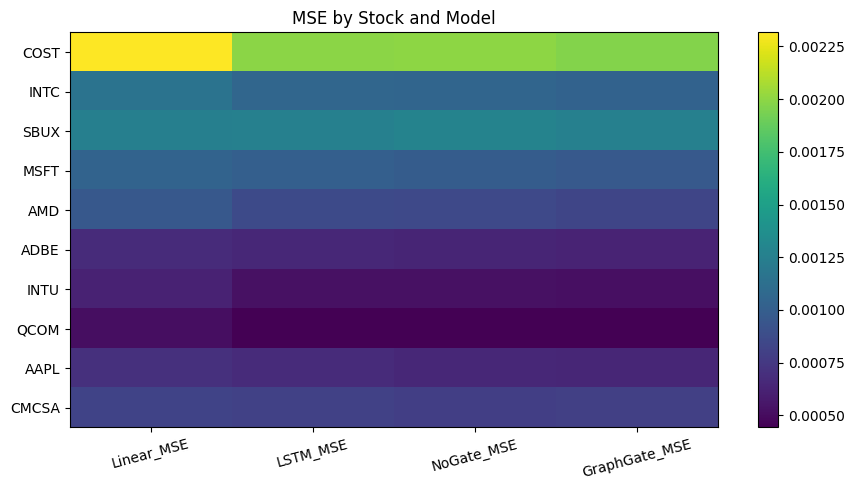

,Linear_MSE,LSTM_MSE,NoGate_MSE,GraphGate_MSE
Ticker,,,,
COST,0.002316,0.001989,0.002001,0.001968
INTC,0.001157,0.001060,0.001053,0.001029
SBUX,0.001251,0.001262,0.001280,0.001258
MSFT,0.001036,0.001007,0.000991,0.000970
AMD,0.000959,0.000865,0.000854,0.000837
ADBE,0.000673,0.000652,0.000639,0.000626
INTU,0.000623,0.000530,0.000530,0.000521
QCOM,0.000516,0.000448,0.000448,0.000443
AAPL,0.000703,0.000674,0.000650,0.000647


In [26]:
# CELL 23 - Heatmap MSE theo từng mã
# Mục tiêu: trực quan hóa MSE của từng mô hình trên từng ticker.
# Heatmap giúp nhìn nhanh mã nào khó dự đoán và mô hình nào yếu ở từng mã.

heatmap_df = stock_mse_df.set_index("Ticker")[["Linear_MSE", "LSTM_MSE", "NoGate_MSE", "GraphGate_MSE"]]

plt.figure(figsize=(9, 5))
plt.imshow(heatmap_df.values, aspect="auto")
plt.xticks(range(heatmap_df.shape[1]), heatmap_df.columns, rotation=15)
plt.yticks(range(heatmap_df.shape[0]), heatmap_df.index)
plt.title("MSE by Stock and Model")
plt.colorbar()
plt.tight_layout()
plt.show()

heatmap_df


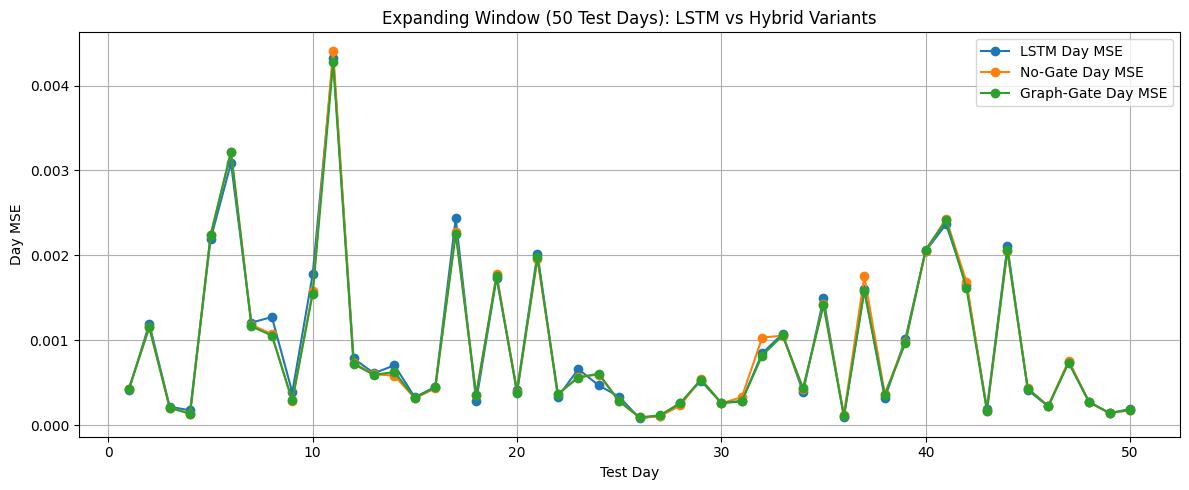

In [27]:
# CELL 24 - Biểu đồ MSE theo từng ngày test
# Mục tiêu: quan sát biến động lỗi theo thời gian giữa LSTM, No-Gate và Graph-Gate.
# Biểu đồ này hỗ trợ giải thích mô hình nào ổn định hơn qua từng giai đoạn thị trường.

plt.figure(figsize=(12, 5))
plt.plot(compare_step_df["Step"], compare_step_df["LSTM_Day_MSE"], label="LSTM Day MSE", marker="o")
plt.plot(compare_step_df["Step"], compare_step_df["NoGate_Day_MSE"], label="No-Gate Day MSE", marker="o")
plt.plot(compare_step_df["Step"], compare_step_df["GraphGate_Day_MSE"], label="Graph-Gate Day MSE", marker="o")
plt.title("Expanding Window (50 Test Days): LSTM vs Hybrid Variants")
plt.xlabel("Test Day")
plt.ylabel("Day MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
# CELL 25 - Kiểm chứng train 2020-2021 và test 50 ngày kế tiếp
# Mục tiêu: tái sử dụng pipeline cũ cho window phụ, không ghi đè kết quả chính.
# Graph-Gate được calibration bằng validation để giảm rủi ro graph làm nhiễu.

VERIFY_WINDOW_NAME = "Train 2020-2021 + Test 50 ngày kế tiếp"
VERIFY_TEST_START_DATE = "2022-01-01"
VERIFY_TEST_DAYS = 50

def resolve_forward_test_indices(dates, start_date, n_days):
    """Lấy n_days ngày giao dịch đầu tiên kể từ start_date."""
    date_index = pd.DatetimeIndex(dates)
    candidates = np.where(date_index >= pd.Timestamp(start_date))[0].astype(int)
    if len(candidates) < n_days:
        raise ValueError(f"Không đủ {n_days} ngày test sau {start_date}.")
    return candidates[:n_days]

verify_test_indices = resolve_forward_test_indices(dates, VERIFY_TEST_START_DATE, VERIFY_TEST_DAYS)
verify_first_test_t = int(verify_test_indices[0])

verify_scaled_features_3d, _, _, _, verify_train_start_t, verify_train_end_t = fit_and_scale_for_expanding_initial_window(
    features_3d,
    first_test_t=verify_first_test_t,
    initial_train_days=EXP_INITIAL_TRAIN_DAYS
)
verify_close_only_3d = verify_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
verify_full_node_3d = verify_scaled_features_3d.copy()

print("Verification window:", VERIFY_WINDOW_NAME)
print("Initial train start:", dates[verify_train_start_t])
print("Initial train end:", dates[verify_train_end_t])
print("Test start:", dates[verify_test_indices[0]])
print("Test end:", dates[verify_test_indices[-1]])
print("Số ngày test:", len(verify_test_indices))

verify_linear_metrics, verify_linear_step_df, verify_linear_pred, verify_linear_true, verify_linear_last = run_expanding_linear_backtest(
    test_indices=verify_test_indices,
    first_test_t=verify_first_test_t,
    close_only_3d=verify_close_only_3d,
    full_node_3d=verify_full_node_3d,
    log_prefix="[Verify Linear]"
)

(
    verify_lstm_metrics, verify_lstm_step_df, verify_lstm_pred, verify_lstm_true, verify_lstm_last,
    verify_no_gate_metrics, verify_no_gate_step_df, verify_no_gate_pred, verify_no_gate_true, verify_no_gate_last,
    verify_graph_gate_metrics, verify_graph_gate_step_df, verify_graph_gate_pred, verify_graph_gate_true, verify_graph_gate_last,
    verify_graph_step_df, verify_gate_step_df
) = run_joint_expanding_lstm_hybrid_backtest(
    test_indices=verify_test_indices,
    first_test_t=verify_first_test_t,
    close_only_3d=verify_close_only_3d,
    full_node_3d=verify_full_node_3d,
    log_prefix="[Verify] ",
    calibrate_graph_gate=True
)

verify_results_df = pd.DataFrame([
    {"Window": VERIFY_WINDOW_NAME, "Model": "Linear Regression (Expanding)", **verify_linear_metrics},
    {"Window": VERIFY_WINDOW_NAME, "Model": "LSTM (Expanding)", **verify_lstm_metrics},
    {"Window": VERIFY_WINDOW_NAME, "Model": "Hybrid LSTM-GNN No-Gate (Expanding)", **verify_no_gate_metrics},
    {"Window": VERIFY_WINDOW_NAME, "Model": "Hybrid LSTM-GNN Graph-Gate Calibrated (Expanding)", **verify_graph_gate_metrics},
]).sort_values("MSE").reset_index(drop=True)

verify_results_df


Verification window: Train 2020-2021 + Test 50 ngày kế tiếp
Initial train start: 2020-01-03 00:00:00
Initial train end: 2021-12-31 00:00:00
Test start: 2022-01-03 00:00:00
Test end: 2022-03-15 00:00:00
Số ngày test: 50
[Verify Linear] Step 01/50 | Date=2022-01-03 | Day_MSE=0.001041
[Verify Linear] Step 10/50 | Date=2022-01-14 | Day_MSE=0.000807
[Verify Linear] Step 20/50 | Date=2022-01-31 | Day_MSE=0.001879
[Verify Linear] Step 30/50 | Date=2022-02-14 | Day_MSE=0.000064
[Verify Linear] Step 40/50 | Date=2022-03-01 | Day_MSE=0.001416
[Verify Linear] Step 50/50 | Date=2022-03-15 | Day_MSE=0.001480
[Verify] Step 01/50 | Date=2022-01-03 | LSTM_MSE=0.000917 | NoGate_MSE=0.000953 | GraphGate_MSE=0.000953 | Alpha=0.00 | GateMean=1.000
[Verify] Step 10/50 | Date=2022-01-14 | LSTM_MSE=0.000768 | NoGate_MSE=0.000803 | GraphGate_MSE=0.000797 | Alpha=1.00 | GateMean=0.832
[Verify] Step 20/50 | Date=2022-01-31 | LSTM_MSE=0.002208 | NoGate_MSE=0.002318 | GraphGate_MSE=0.002277 | Alpha=1.00 | GateMea

,Window,Model,MSE,MAE,RMSE,Directional_Accuracy
0,Train 2020-2021 + Test 50 ngày kế tiếp,LSTM (Expanding),0.001160,0.026596,0.034061,0.518
1,Train 2020-2021 + Test 50 ngày kế tiếp,Hybrid LSTM-GNN Graph-Gate Calibrated (Expanding),0.001162,0.026614,0.034083,0.516
2,Train 2020-2021 + Test 50 ngày kế tiếp,Hybrid LSTM-GNN No-Gate (Expanding),0.001163,0.026638,0.034108,0.526
3,Train 2020-2021 + Test 50 ngày kế tiếp,Linear Regression (Expanding),0.001196,0.026963,0.034585,0.448
